### Using the Perceptron classifier on IRIS Dataset

### Loading IRIS Dataset into a Pandas DataFrame object

In [1]:
import pandas as pd
import os 

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('URL:', s)

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


In [2]:
df = pd.read_csv(s, header = None, encoding= 'utf-8')
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Selecting Setosa and Versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == "Iris-setosa", -1, 1)
print(y)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1]


In [ ]:
# Extract only sepal length and petal length features

X = df.iloc[0:100, [0,2]].values
print(X[:5])

[[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]


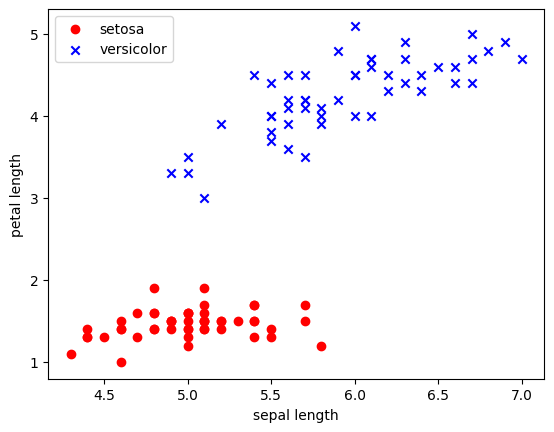

In [12]:
# Plot the data

# Sepal and Petal length for setosa
plt.scatter(X[:50, 0], X[:50, 1], color = "r", label = "setosa", marker = "o")
plt.scatter(X[50:100, 0], X[50:100 , 1] ,color = "b", label = "versicolor", marker = "x")
plt.xlabel("sepal length")
plt.ylabel("petal length")
plt.legend()
plt.show()

In [21]:
import numpy as np

class Perceptron(object) : 
    def __init__(self, eta = 0.01, n_iter = 50, random_state = 1):
        
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        
    def fit(self, X, y) :
        """
        We do not initialize weight values to 0 because, setting it to zero the update passes will only
        affect the scale of the weights but not the direction, which is important for classification tasks
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_  = rgen.normal(loc = 0.0, scale = 0.01, size = 1 + X.shape[1])
        self.error_  = []
        
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                
                self.w_[1:] += update * xi
                self.w_[0] += update 
                errors += int(update != 0.0)
            self.error_.append(errors)  
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0] 
    
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0 , 1, -1)

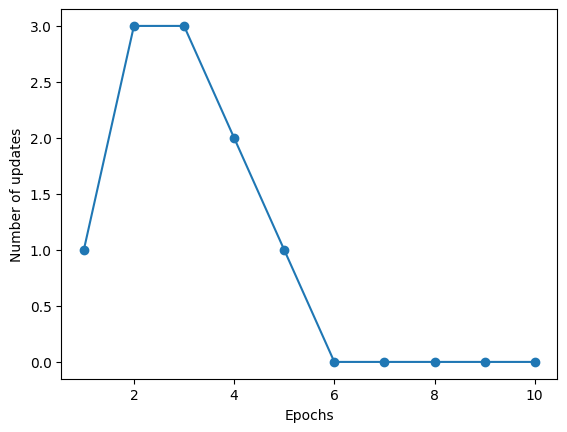

In [22]:
# Training
ppn = Perceptron(eta = 0.1, n_iter = 10)

ppn.fit(X, y)

plt.plot(range(1,len(ppn.error_) + 1), ppn.error_, marker = "o")
plt.xlabel("Epochs")
plt.ylabel("Number of updates")
plt.show()

In [23]:
# Plotting decision regions
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

C:\Users\sayed mohamed saqib\AppData\Local\Temp\ipykernel_16248\1356673747.py:25: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


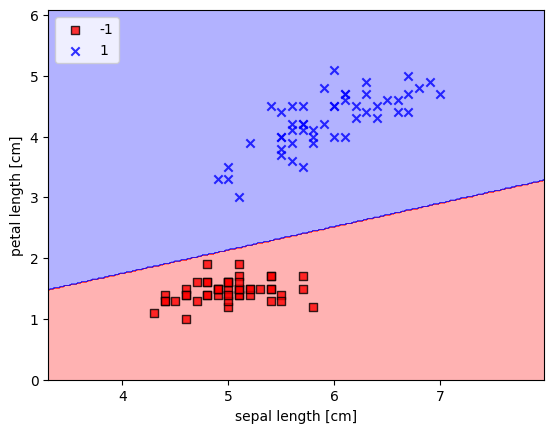

In [ ]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')


plt.show()